#### Importing the libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import subprocess

try:
    subprocess.check_call(['pip', 'install', 'buckaroo'])
except subprocess.CalledProcessError as e:
    print(f"Error installing buckaroo: {e}")
    
import buckaroo


#### Reading the CSV Files

In [11]:
# Read the csv

# Specify the data types for the columns with mixed types
#dtype_options = {'BOROUGH': str}  

# Read the CSV file with specified data types and low_memory=False
#filedf = pd.read_csv("Motor_Vehicle_Collisions_Crashes.csv", dtype=dtype_options, low_memory=False)


filedf = pd.read_csv("Motor_Vehicle_Collisions_Crashes.csv",low_memory=False)

#### Number of Records in File

In [12]:
filedf.shape[0]
print(len(filedf))

1987321


#### No of columns

In [13]:
filedf.shape[1]

29

#### Top 5 records

In [14]:
print(filedf.head())

   CRASH DATE CRASH TIME   BOROUGH ZIP CODE   LATITUDE  LONGITUDE  \
0  09/11/2021       2:39       NaN      NaN        NaN        NaN   
1  03/26/2022      11:45       NaN      NaN        NaN        NaN   
2  06/29/2022       6:55       NaN      NaN        NaN        NaN   
3  09/11/2021       9:35  BROOKLYN    11208  40.667202 -73.866500   
4  12/14/2021       8:13  BROOKLYN    11233  40.683304 -73.917274   

                  LOCATION           ON STREET NAME CROSS STREET NAME  \
0                      NaN    WHITESTONE EXPRESSWAY         20 AVENUE   
1                      NaN  QUEENSBORO BRIDGE UPPER               NaN   
2                      NaN       THROGS NECK BRIDGE               NaN   
3    (40.667202, -73.8665)                      NaN               NaN   
4  (40.683304, -73.917274)          SARATOGA AVENUE    DECATUR STREET   

           OFF STREET NAME  ...  CONTRIBUTING FACTOR VEHICLE 2  \
0                      NaN  ...                    Unspecified   
1             

#### Bottom 5 records

In [15]:
print(filedf.tail())

         CRASH DATE CRASH TIME   BOROUGH ZIP CODE   LATITUDE  LONGITUDE  \
1987316  04/25/2023      12:15       NaN      NaN  40.570835 -74.169830   
1987317  04/18/2023      21:16     BRONX    10475  40.868320 -73.833170   
1987318  04/19/2023       7:40       NaN      NaN  40.664303 -73.957300   
1987319  04/03/2023      15:50  BROOKLYN    11225  40.661568 -73.950730   
1987320  04/25/2023      19:05       NaN      NaN  40.748848 -73.872375   

                        LOCATION    ON STREET NAME CROSS STREET NAME  \
1987316   (40.570835, -74.16983)   RICHMOND AVENUE               NaN   
1987317    (40.86832, -73.83317)      EDSON AVENUE     BARTOW AVENUE   
1987318    (40.664303, -73.9573)    BEDFORD AVENUE               NaN   
1987319   (40.661568, -73.95073)   NOSTRAND AVENUE      LINCOLN ROAD   
1987320  (40.748848, -73.872375)  ROOSEVELT AVENUE               NaN   

        OFF STREET NAME  ...  CONTRIBUTING FACTOR VEHICLE 2  \
1987316             NaN  ...                    Unspe

#### Dropping a column Collision id

In [39]:
newdf=filedf.drop('COLLISION_ID', axis=1)
#print(newdf.head())
newdf.shape[0]
newdf.shape[1]

28

#### Dropping empty values in column"LOCATION"

In [40]:
newdf.drop(newdf[newdf['LOCATION'].isna()].index, inplace= True)
newdf.shape[0]
#newdf1=newdf.dropna(subset=['LOCATION'])
#newdf1.shape[0]

1760099

#### Dropping empty values in column"VEHICLE TYPE CODE 1"

In [18]:
newdf.drop(newdf[newdf['VEHICLE TYPE CODE 1'].isna()].index, inplace= True)
newdf.shape[0]

1748967

#### Dropping empty values and unwanted rows in column"CONTRIBUTING FACTOR VEHICLE 1"

In [19]:
newdf.drop(newdf[newdf['CONTRIBUTING FACTOR VEHICLE 1'].isna()].index, inplace= True)
newdf.drop(newdf[newdf['CONTRIBUTING FACTOR VEHICLE 1']=='80'].index, inplace=True)
newdf.drop(newdf[newdf['CONTRIBUTING FACTOR VEHICLE 1']=='1'].index, inplace=True)
newdf.shape[0]

1746602

#### Dropping empty values in column"NUMBER OF PERSONS INJURED"

In [20]:
newdf.drop(newdf[newdf['NUMBER OF PERSONS INJURED'].isna()].index, inplace= True)
newdf.shape[0]

1746590

#### Dropping empty values in column"NUMBER OF PERSONS KILLED"

In [21]:
newdf.drop(newdf[newdf['NUMBER OF PERSONS KILLED'].isna()].index, inplace= True)
newdf.shape[0]

1746577

#### No of accidents date wise

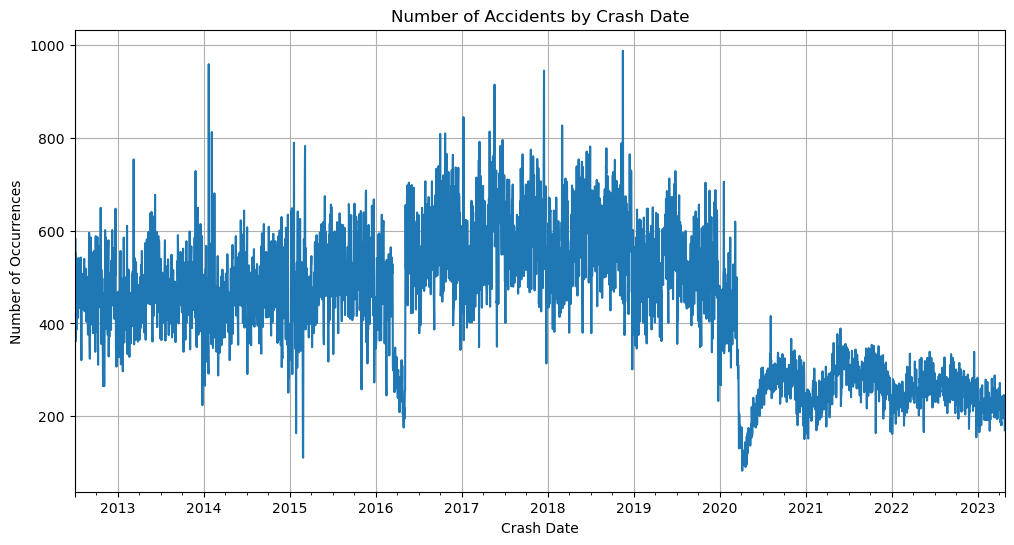

In [22]:
newdf['CRASH DATE'] = pd.to_datetime(newdf['CRASH DATE'])
date_counts = newdf['CRASH DATE'].value_counts().sort_index()
date_counts.plot(kind='line', figsize=(12, 6))
plt.xlabel('Crash Date')
plt.ylabel('Number of Occurrences')
plt.title('Number of Accidents by Crash Date')
plt.grid(True)
plt.show()

#### No of accidents based on the BOROUGH

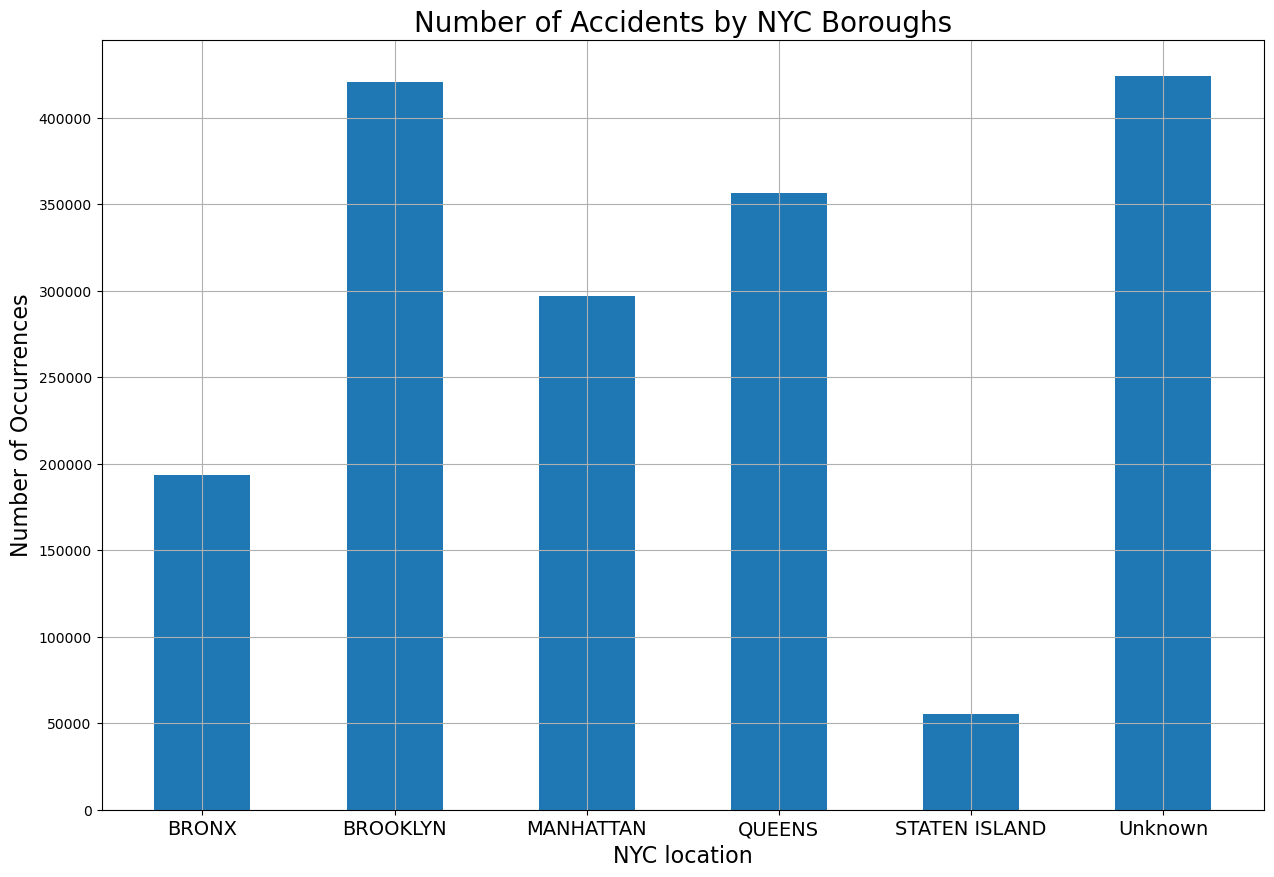

In [23]:
borough_location = newdf['BOROUGH'].value_counts().sort_index()
borough_location
unknown_val      = newdf['BOROUGH'].isna().value_counts().sort_index()
unknown_val
borough_location = pd.concat([borough_location, pd.Series([unknown_val[True]], index=['Unknown'])])
borough_location
plt.figure(figsize=(15, 10))
plt.bar(borough_location.index,borough_location, width=0.5 ,align='center')
plt.xlabel('NYC location',fontsize=16)
plt.xticks(rotation=0, fontsize=14)
plt.ylabel('Number of Occurrences', fontsize= 16)
plt.title('Number of Accidents by NYC Boroughs', fontsize=20)
plt.grid(True)
plt.show()

#### Scatter plot for the time zones of the data

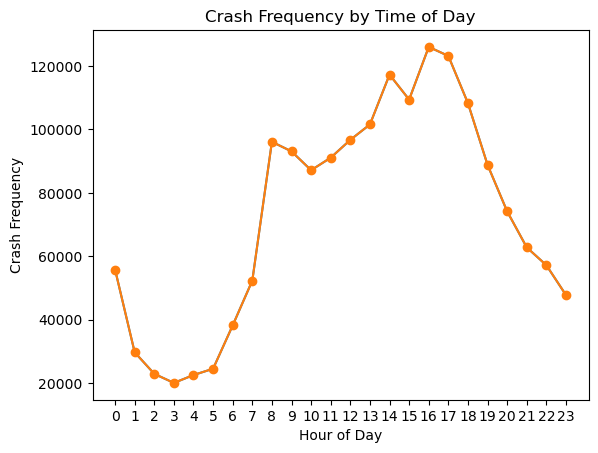

In [34]:
newdf['CRASH DATE'] = pd.to_datetime(newdf['CRASH DATE'])
newdf['CRASH TIME'] = pd.to_datetime(newdf['CRASH TIME'])
newdf['CRASH HOUR'] = newdf['CRASH TIME'].dt.hour
crash_frequency=newdf['CRASH HOUR'].value_counts().sort_index()
#plt.figure(figsize=(10,6))
plt.plot(crash_frequency.index,crash_frequency)
crash_frequency.plot(kind='line',marker = 'o')
plt.xlabel('Hour of Day')
plt.ylabel('Crash Frequency')
plt.title('Crash Frequency by Time of Day')
plt.xticks(range(24))
plt.show()

In [33]:
crash_frequency[1]

29678